In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/content/Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [6]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [7]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [8]:
df.drop(columns= ['RowNumber','CustomerId',   'Surname'],inplace = True)

In [9]:
df2 = pd.get_dummies(df,columns = ['Geography','Gender'],drop_first = True)

In [10]:

pip install scikit-learn

In [11]:
X = df2.drop(columns = ['Exited'])
y = df2['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state= 1)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [15]:
pip install tensorflow keras

In [14]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [27]:
model = Sequential()

model.add(Dense(11,activation = 'relu',input_dim = 11))
model.add(Dense(11,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(loss = 'binary_crossentropy',optimizer = 'Adam',metrics = ['accuracy'])

In [46]:
history = model.fit(X_train_scaled,y_train,epochs = 100,validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8647 - loss: 0.3275 - val_accuracy: 0.8531 - val_loss: 0.3391
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8659 - loss: 0.3277 - val_accuracy: 0.8519 - val_loss: 0.3391
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8655 - loss: 0.3275 - val_accuracy: 0.8519 - val_loss: 0.3414
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8652 - loss: 0.3279 - val_accuracy: 0.8531 - val_loss: 0.3416
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8659 - loss: 0.3279 - val_accuracy: 0.8525 - val_loss: 0.3401
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8659 - loss: 0.3276 - val_accuracy: 0.8531 - val_loss: 0.3397
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8648 - loss: 0.3275 - val_accuracy: 0.8562 - val_loss: 0.3400
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8652 - loss: 0.3273 - val_accu

In [35]:
model.layers[0].get_weights()

[array([[ 2.9919114e-02, -1.4044559e-02, -1.2704840e-01,  2.6561630e-01,
          1.9541098e-01, -5.9155311e-02,  3.5754874e-02,  3.8905615e-01,
          2.6380083e-01, -1.8831949e-01,  1.8411213e-01],
        [ 8.3091921e-01, -6.3800156e-01, -6.6100520e-01, -8.5058606e-01,
          1.6179635e-01,  8.2069069e-01,  3.7315944e-01, -4.0388834e-01,
          2.4655737e-01, -2.7675822e-01, -2.5238582e-01],
        [ 1.9874661e-01,  2.1529971e-01,  4.2143408e-02,  1.8170926e-01,
          2.3434477e-01,  4.5448031e-02, -1.5894284e-02, -3.7961042e-01,
          8.9902349e-02, -3.3223224e-01, -4.0033881e-02],
        [-1.4316478e-01, -1.4099680e-01, -1.8067358e-01,  4.5689818e-02,
         -4.2646217e-01, -3.2790703e-01,  4.7564246e-02, -5.6019336e-01,
         -3.5702330e-01, -1.7416988e-01, -7.1384263e-01],
        [ 3.2116854e-01, -1.4051943e-01, -3.5160670e-01, -1.3666184e-01,
         -3.9787468e-01, -1.2580947e+00,  9.8707581e-01,  2.7375853e-01,
          6.2695557e-01, -1.2757418e-0

In [47]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [48]:
y_pred= np.where(y_log > 0.5,1,0)

In [49]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.866

In [50]:


import matplotlib.pyplot as plt

In [51]:
history.history

{'accuracy': [0.8646875023841858,
  0.8659374713897705,
  0.8654687404632568,
  0.8651562333106995,
  0.8659374713897705,
  0.8659374713897705,
  0.8648437261581421,
  0.8651562333106995,
  0.8654687404632568,
  0.8657812476158142,
  0.8667187690734863,
  0.8645312786102295,
  0.8654687404632568,
  0.8645312786102295,
  0.8656250238418579,
  0.8657812476158142,
  0.8653125166893005,
  0.8670312762260437,
  0.8671875,
  0.8651562333106995,
  0.8635937571525574,
  0.8667187690734863,
  0.8650000095367432,
  0.8651562333106995,
  0.8670312762260437,
  0.8659374713897705,
  0.8673437237739563,
  0.8643749952316284,
  0.8673437237739563,
  0.8660937547683716,
  0.8657812476158142,
  0.866406261920929,
  0.8654687404632568,
  0.8660937547683716,
  0.8684375286102295,
  0.8656250238418579,
  0.8656250238418579,
  0.866406261920929,
  0.8660937547683716,
  0.866406261920929,
  0.8682812452316284,
  0.8673437237739563,
  0.8682812452316284,
  0.8671875,
  0.8671875,
  0.8681250214576721,
  0.86

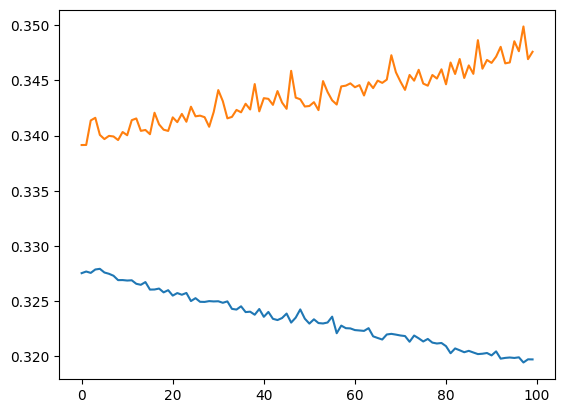

In [52]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [53]:
!git clone https://github.com/Shikha09456/Learning_deep_learning.git


Cloning into 'Learning_deep_learning'...


In [54]:
%cd Learning_deep_learning

/content/Learning_deep_learning


In [56]:
!git config --global user.name "Shikha09456"
!git config --global user.email "shikha28052003@gmail.com"

In [57]:
!git add .

In [58]:
!git status

On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [59]:
!git commit -m "Add Google Colab notebooks"

On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)


In [62]:
!git push origin main

error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Shikha09456/Learning_deep_learning.git'


In [63]:
%cd /content/Learning_deep_learning

/content/Learning_deep_learning


In [64]:
!git status


On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [65]:
!git branch

In [66]:
!git add .

In [67]:
!git commit -m "Add deep learning code"


On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)


In [68]:
!git status

On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [69]:
!pwd
!ls


/content/Learning_deep_learning


In [70]:
%cd /content/Learning_deep_learning

/content/Learning_deep_learning


In [71]:
!ls